In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
#data load kiya h
df = pd.read_csv("Titanic-Dataset.csv")
print("Data sucessfully loaded")
print(df)

Data sucessfully loaded
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                           

In [3]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

# Sirf numerical columns select karo
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


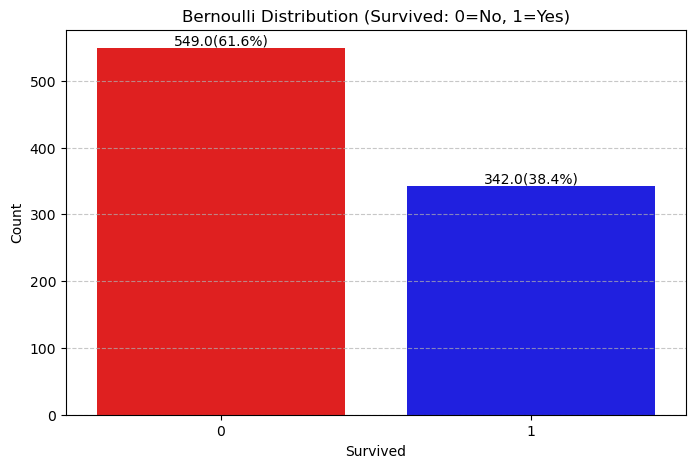

Probabilities:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [74]:
#count how many female and male in titanic are survived and also write their probbaility.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Countplot
ax = sns.countplot(x='Survived', data=df,hue='Survived', palette={0: "red", 1: "blue"},legend=False)

# Labels (Count + Percentage)
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    
    ax.annotate(f'{count}({percentage:.1f}%)',(p.get_x() + p.get_width()/2., count),ha='center', va='bottom')

plt.title("Bernoulli Distribution (Survived: 0=No, 1=Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Probabilities
print("Probabilities:")
print(df['Survived'].value_counts(normalize=True))

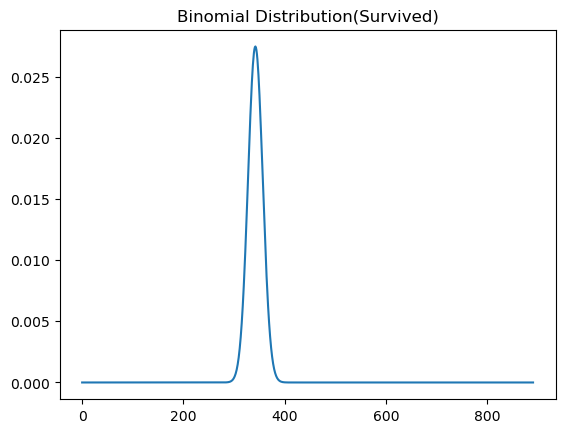

Total Passengers (n): 891
Probability of survival (p): 0.384


In [75]:
#apply poisson distribution on survived column 

from scipy.stats import binom
import numpy as np

n = len(df['Survived'])
p = df['Survived'].mean()

x = np.arange(0, n)
y = binom.pmf(x, n, p)

plt.plot(x, y)
plt.title("Binomial Distribution(Survived)")
plt.show()


# Print basic stats
print(f"Total Passengers (n): {n}")
print(f"Probability of survival (p): {p:.3f}")

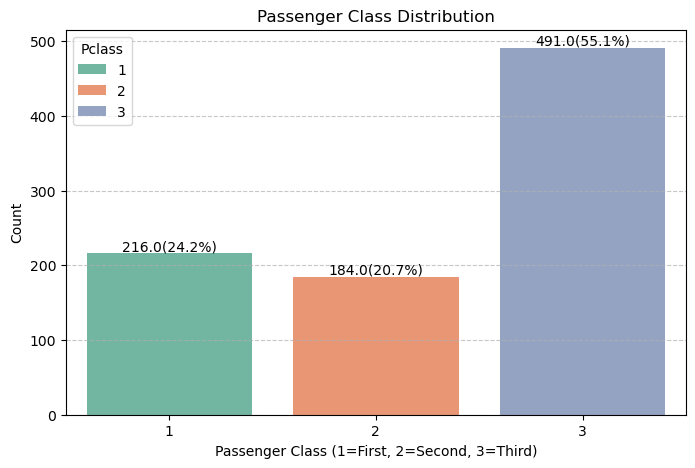

Passenger Class Probabilities:
Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [76]:
#count how many people in upperclass,middleclass and poorclass also write their probbaility.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Countplot 
ax = sns.countplot(x='Pclass', data=df,hue='Pclass',palette='Set2')

# Total passengers
total = len(df)

# Add counts + percentage on each bar
for p in ax.patches:
    count = p.get_height()
    if count>0:
        percentage = 100 * count / total
        ax.annotate(f'{count}({percentage:.1f}%)',(p.get_x() + p.get_width()/2., count),ha='center', va='bottom')

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class (1=First, 2=Second, 3=Third)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Print probability of each class
print("Passenger Class Probabilities:")
print(df['Pclass'].value_counts(normalize=True))

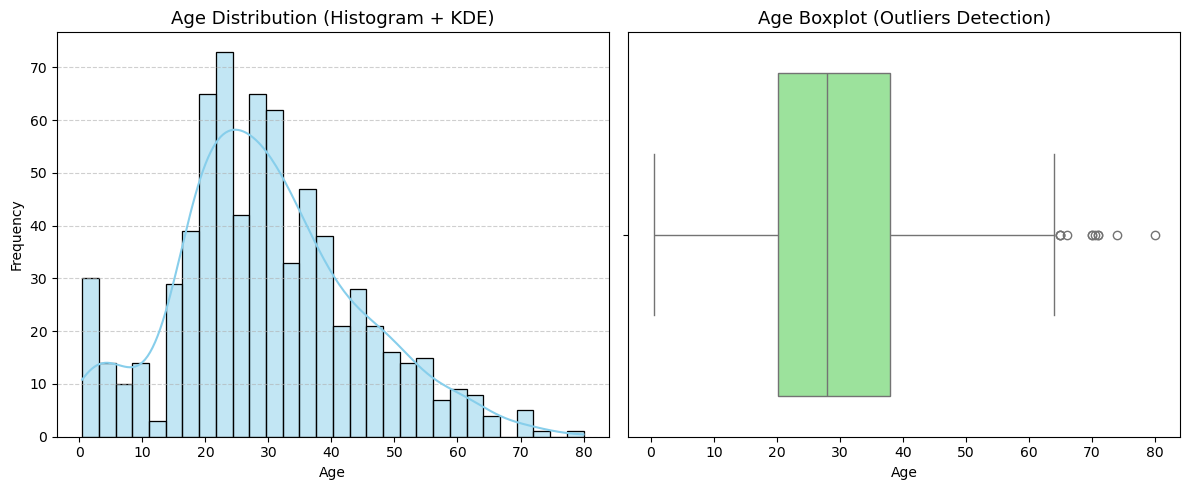

Shapiro-Wilk Test Results:
Statistic = 0.9815
p-value = 0.00000
Result: Data is NOT normal


In [63]:
#apply normal distribution on age column and tell data is normal or not
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import numpy as np

plt.figure(figsize=(12,5))

# Histogram + KDE
plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True, bins=30, color='skyblue')
plt.title("Age Distribution (Histogram + KDE)", fontsize=13)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Boxplot (outliers check)
plt.subplot(1,2,2)
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title("Age Boxplot (Outliers Detection)", fontsize=13)
plt.xlabel("Age")
plt.tight_layout()
plt.show()

# Normality Test

data = df['Age'].dropna()
stat, p = shapiro(data)
print("Shapiro-Wilk Test Results:")
print(f"Statistic = {stat:.4f}")        # ya btata h ky data normal ky kitny gareeb h
print(f"p-value = {p:.5f}")

# Decision
alpha = 0.05
if p > alpha:
    print("Result: Data is approximately NORMAL")
else:
    print("Result: Data is NOT normal")

Lambda (mean): 0.5230078563411896


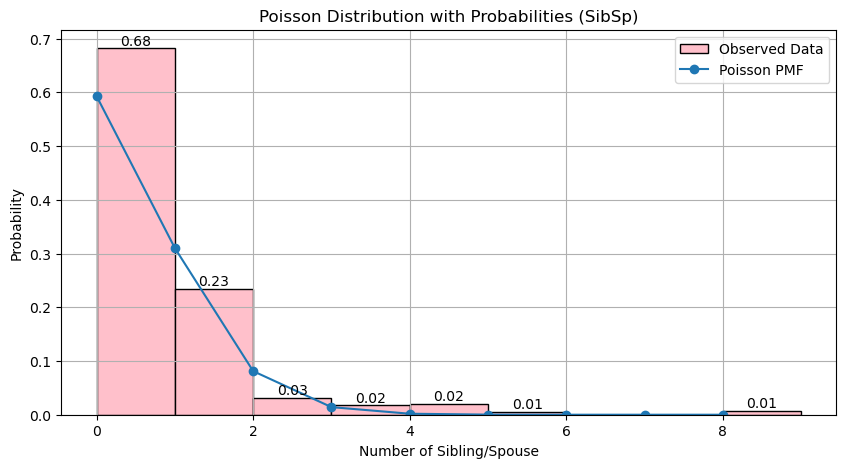

In [77]:
#apply poisson distribution on Sibling/Spouse column

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

data = df['SibSp']
lam = data.mean()
print("Lambda (mean):", lam)
plt.figure(figsize=(10,5))

# Histogram (counts nikalne ke liye)
counts, bins, patches= plt.hist(data, bins=range(0, data.max()+2),color='pink', label='Observed Data',density=True, edgecolor='black')

# Har bar ke upar value likhna
for i in range(len(patches)):
    height = counts[i]
    if height > 0:
        plt.text(patches[i].get_x() + patches[i].get_width()/2,height,f"{height:.2f}",ha='center', va='bottom')

# Poisson curve
x = np.arange(0, data.max()+1)
pmf = poisson.pmf(x, lam)
plt.plot(x, pmf, marker='o', label='Poisson PMF')

plt.title("Poisson Distribution with Probabilities (SibSp)")
plt.xlabel("Number of Sibling/Spouse")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

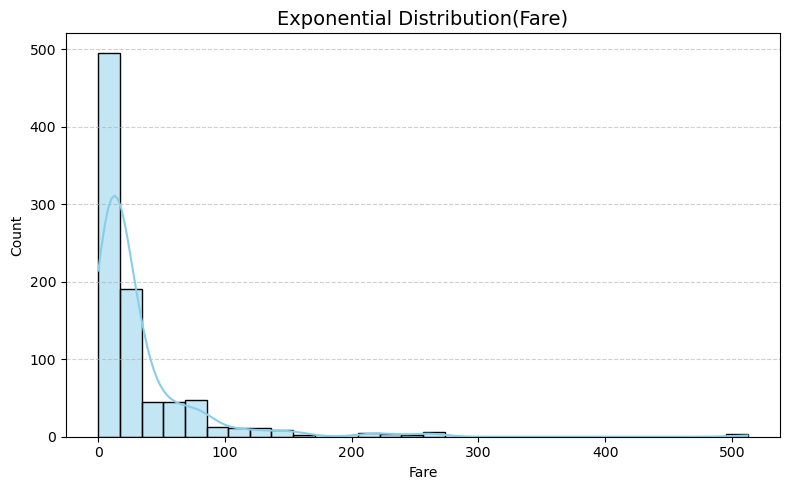

In [66]:
#apply exponential distribution on fare column
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import expon, shapiro
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], kde=True, color='skyblue', bins=30)
plt.title("Exponential Distribution(Fare)", fontsize=14)
plt.xlabel("Fare")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


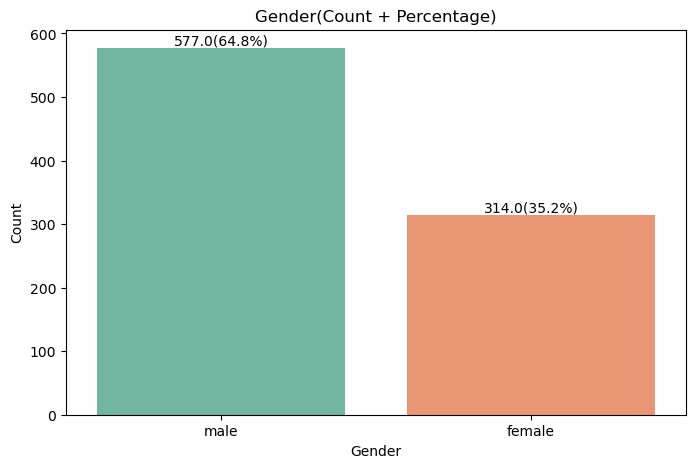

In [73]:
#count how many female and male in titanic also write their probbaility.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
ax = sns.countplot(x='Sex', data=df,hue='Sex',palette='Set2')

# Total count
total = len(df['Sex'])

# Add percentage labels
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{count}({percentage:.1f}%)',(p.get_x() + p.get_width()/2., count),ha='center', va='bottom')

plt.title("Gender(Count + Percentage)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

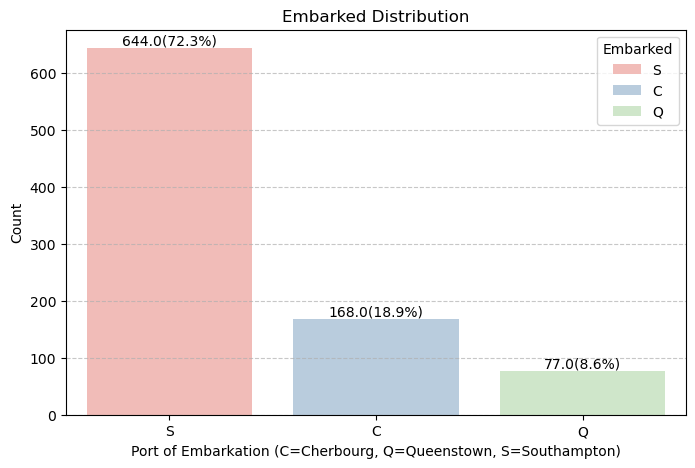

Embarked Probabilities:
Embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64


In [46]:
#Which stations(C=Cherbourg, Q=Queenstown or S=Southampton) did people use to board the Titanic? count and 
# also write their probbaility.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Countplot with nice palette
ax = sns.countplot(x='Embarked', hue='Embarked',data=df, palette='Pastel1')

# Total passengers
total = len(df)

# Add counts + percentage labels on each bar
for p in ax.patches:
    count = p.get_height()
    if count>0:
        percentage = 100 * count / total
        ax.annotate(f'{count}({percentage:.1f}%)',(p.get_x() + p.get_width()/2., count),ha='center', va='bottom')

plt.title("Embarked")
plt.xlabel("Port of Embarkation (C=Cherbourg, Q=Queenstown, S=Southampton)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Print probabilities of each port
print("Embarked Probabilities:")
print(df['Embarked'].value_counts(normalize=True))

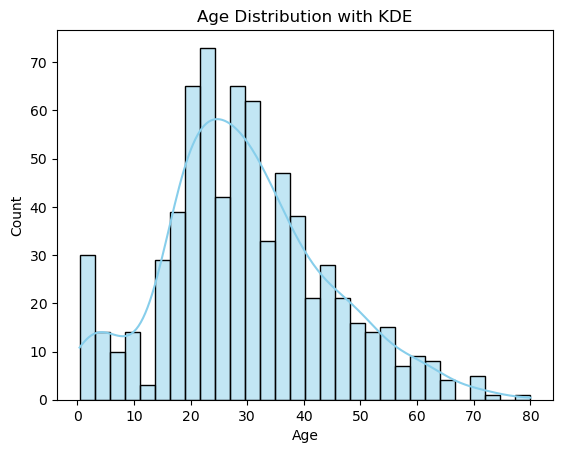

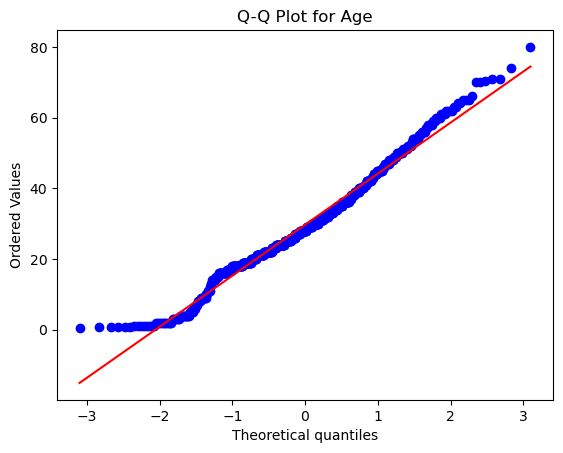

Shapiro-Wilk Test: stat=0.981, p=0.000
Age is NOT normally distributed ❌


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

# Histogram + KDE
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title("Age Distribution with KDE")
plt.show()

# Q-Q plot
import scipy.stats as stats
stats.probplot(df['Age'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot for Age")
plt.show()

# Shapiro test
stat, p = shapiro(df['Age'].dropna())
print(f"Shapiro-Wilk Test: stat={stat:.3f}, p={p:.3f}")
if p > 0.05:
    print("Age is approximately normally distributed ✅")
else:
    print("Age is NOT normally distributed ❌")

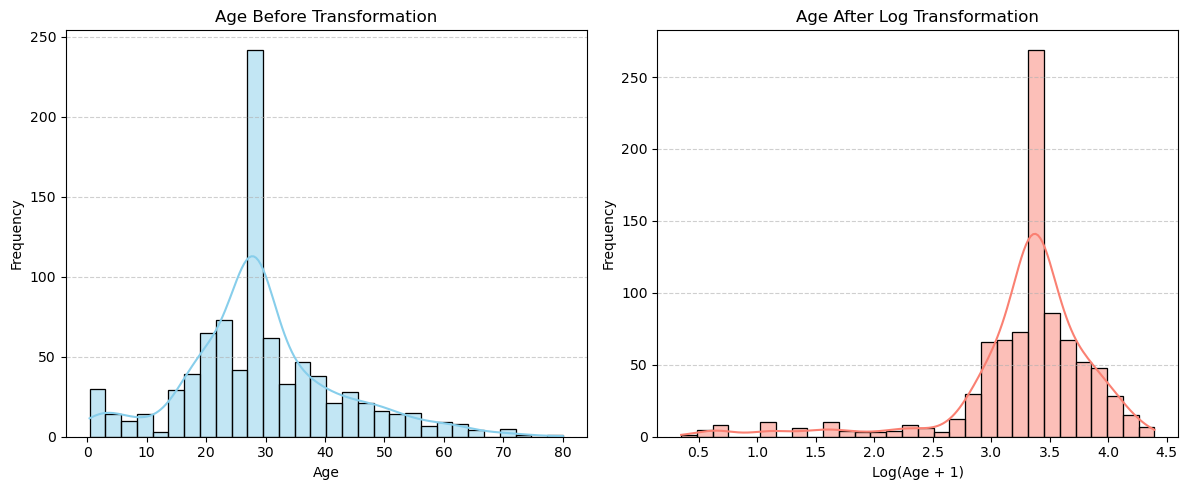

Before Log p-value: 4.651141686041376e-16
After Log p-value: 1.4194995708421865e-32
No major improvement (Age already near normal)


In [72]:
#chk age before and after log transformation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Fill missing values 
df['Age_filled'] = df['Age'].fillna(df['Age'].median())

plt.figure(figsize=(12,5))

# BEFORE
plt.subplot(1,2,1)
sns.histplot(df['Age_filled'], kde=True, bins=30, color='skyblue')
plt.title("Age Before Transformation")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# APPLY LOG
df['Age_log'] = np.log1p(df['Age_filled'])

# AFTER
plt.subplot(1,2,2)
sns.histplot(df['Age_log'], kde=True, bins=30, color='salmon')
plt.title("Age After Log Transformation")
plt.xlabel("Log(Age + 1)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# NORMALITY TEST
stat1, p1 = shapiro(df['Age_filled'])
stat2, p2 = shapiro(df['Age_log'])

print("Before Log p-value:", p1)
print("After Log p-value:", p2)

if p2 > p1:
    print("Normality slightly improved")
else:
    print("No major improvement (Age already near normal)")

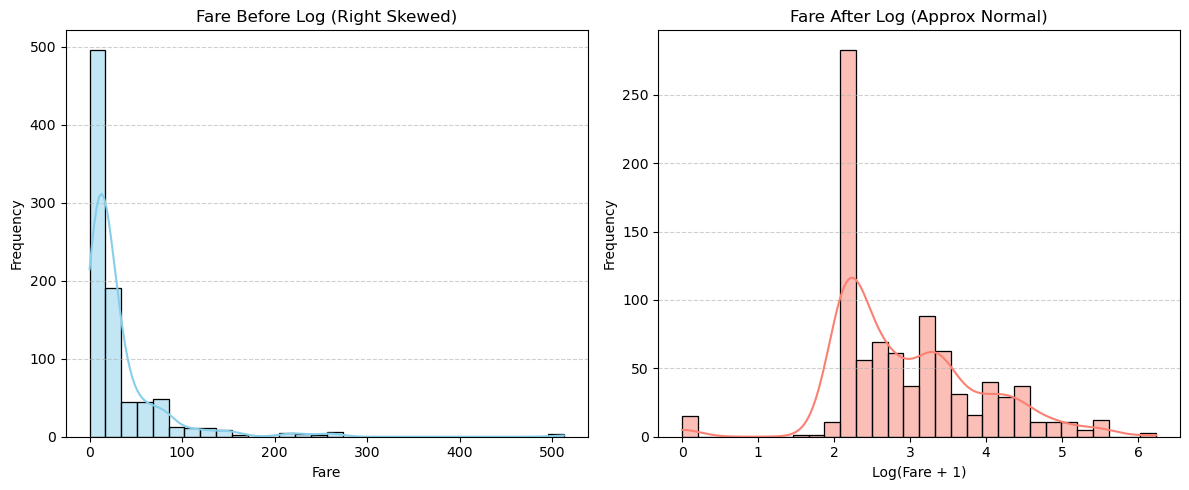

Before Log p-value: 1.0840444395829658e-43
After Log p-value: 6.641862664754367e-22
Normality improved after log transformation


In [70]:
#chk fare before and after log transformation

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

plt.figure(figsize=(12,5))

# -----------------------------
# BEFORE (Skewed Distribution)
plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True, bins=30, color='skyblue')
plt.title("Fare Before Log (Right Skewed)")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# APPLY LOG TRANSFORMATION
df['Fare_log'] = np.log1p(df['Fare'])   # log(1 + x)

# AFTER (More Normal)

plt.subplot(1,2,2)
sns.histplot(df['Fare_log'], kde=True, bins=30, color='salmon')
plt.title("Fare After Log (Approx Normal)")
plt.xlabel("Log(Fare + 1)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#  Shapiro-Wilk test for normality

# Before
stat1, p1 = shapiro(df['Fare'].dropna())

# After
stat2, p2 = shapiro(df['Fare_log'].dropna())

print("Before Log p-value:", p1)
print("After Log p-value:", p2)

if p2 > p1:
    print("Normality improved after log transformation")